<a href="https://colab.research.google.com/github/kalalasrinika-star/-student-profile/blob/main/Unemployment_in_India_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28


In [ ]:
df = df.dropna()
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew dataset shape:", df.shape)

Missing values after cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

New dataset shape: (740, 7)


In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
region_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


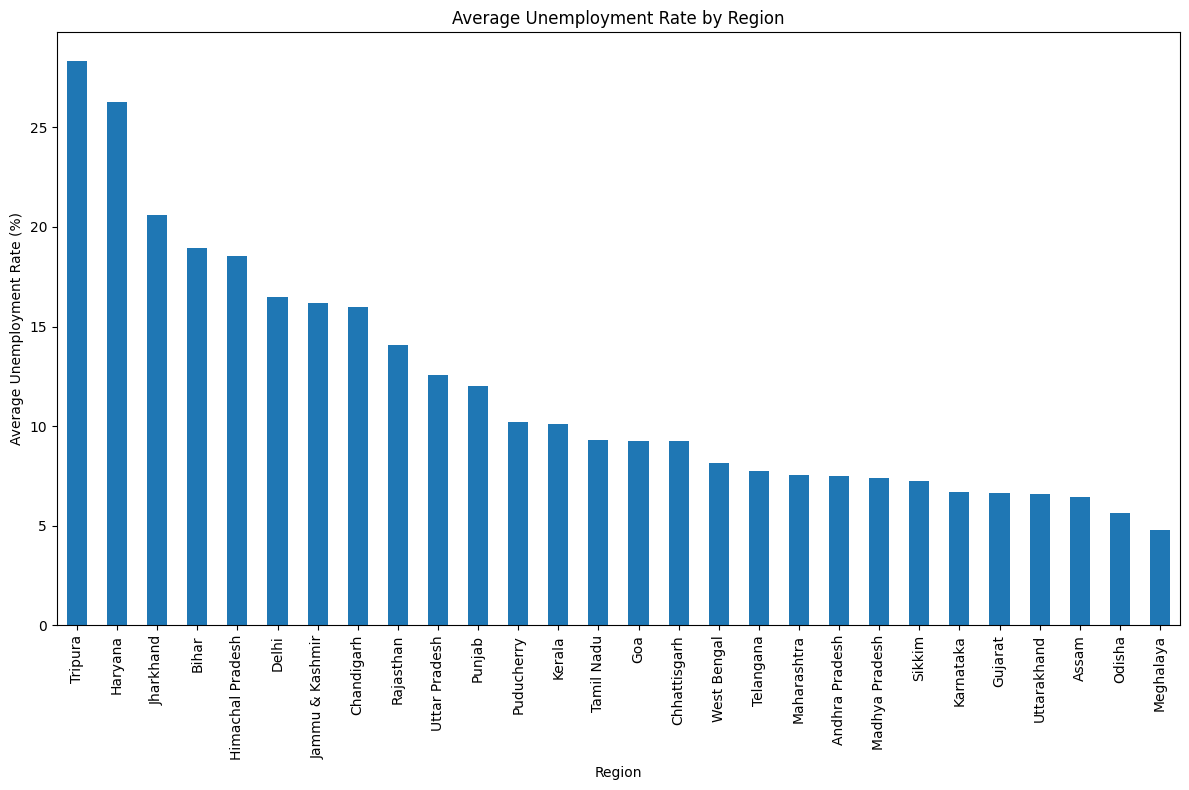

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
region_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
print(df["Date"].min())
print(df["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


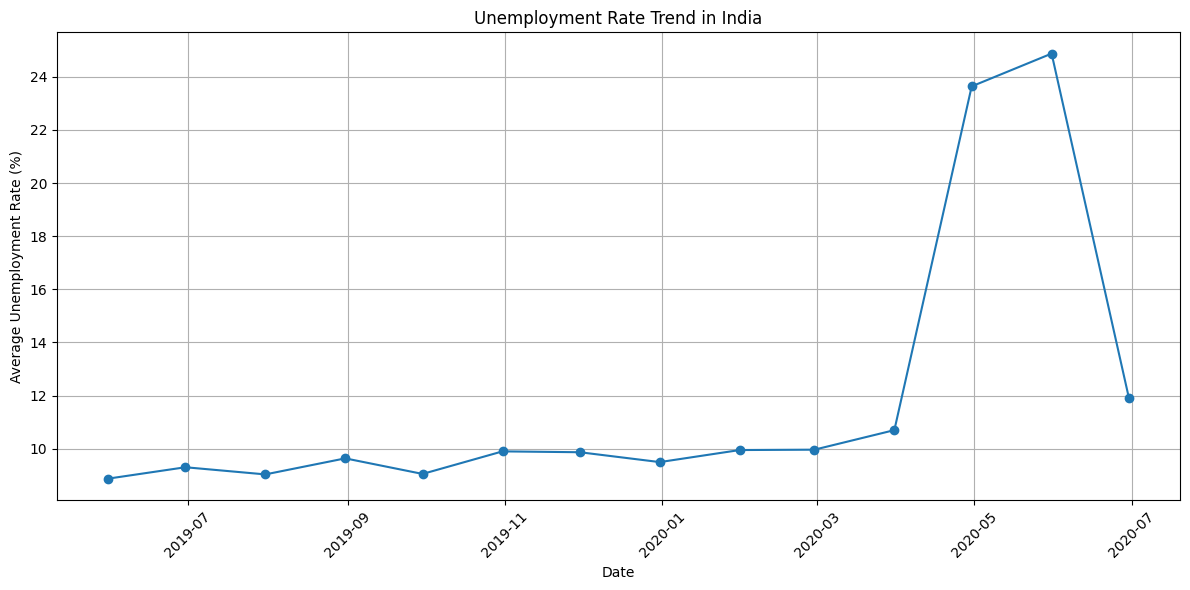

In [ ]:
import matplotlib.pyplot as plt
monthly_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()
plt.figure(figsize=(12, 6))
plt.plot(monthly_unemployment.index, monthly_unemployment.values, marker="o")
plt.title("Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df["Year"] = df["Date"].dt.year
yearly_unemployment = df.groupby("Year")["Estimated Unemployment Rate (%)"].mean()
print("Average Unemployment Rate by Year:")
print(yearly_unemployment)

Average Unemployment Rate by Year:
Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


In [ ]:
increase = (
    (yearly_unemployment[2020] - yearly_unemployment[2019])
    / yearly_unemployment[2019]
) * 100
print(f"Increase in unemployment rate: {increase:.2f}%")

Increase in unemployment rate: 60.67%


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
print(df["Date"].min())
print(df["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [ ]:
df["Year"] = df["Date"].dt.year
yearly_unemployment = df.groupby("Year")["Estimated Unemployment Rate (%)"].mean()
print("Average Unemployment Rate by Year:")
print(yearly_unemployment)

Average Unemployment Rate by Year:
Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


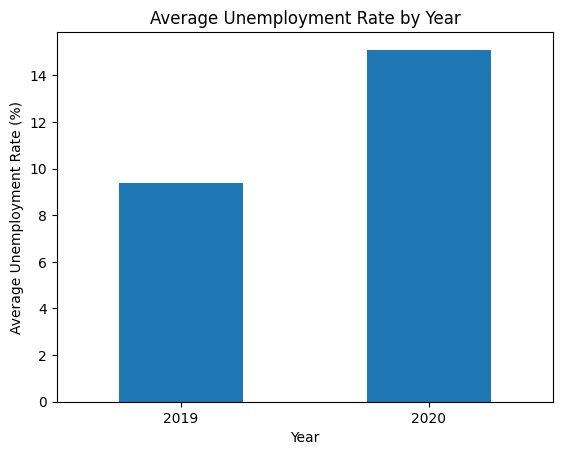

In [ ]:
import matplotlib.pyplot as plt
yearly_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
highest = df.loc[df["Estimated Unemployment Rate (%)"].idxmax()]
print("Highest Unemployment Rate:")
print(highest[["Region", "Date", "Estimated Unemployment Rate (%)"]])

Highest Unemployment Rate:
Region                                      Puducherry
Date                               2020-04-30 00:00:00
Estimated Unemployment Rate (%)                  76.74
Name: 627, dtype: object


In [ ]:
lowest = df.loc[df["Estimated Unemployment Rate (%)"].idxmin()]
print("Lowest Unemployment Rate:")
print(lowest[["Region", "Date", "Estimated Unemployment Rate (%)"]])

Lowest Unemployment Rate:
Region                                           Assam
Date                               2020-06-30 00:00:00
Estimated Unemployment Rate (%)                    0.0
Name: 25, dtype: object


In [ ]:
average_region = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
print("Average Unemployment Rate by Region:")
print(average_region)

Average Unemployment Rate by Region:
Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64


In [ ]:
highest_region = average_region.idxmax()
highest_value = average_region.max()
print("Region with Highest Average Unemployment:")
print(highest_region)
print(f"Average Unemployment Rate: {highest_value:.2f}%")

Region with Highest Average Unemployment:
Tripura
Average Unemployment Rate: 28.35%


In [ ]:
lowest_region = average_region.idxmin()
lowest_value = average_region.min()
print("Region with Lowest Average Unemployment:")
print(lowest_region)
print(f"Average Unemployment Rate: {lowest_value:.2f}%")

Region with Lowest Average Unemployment:
Meghalaya
Average Unemployment Rate: 4.80%


In [ ]:
# COVID-19 impact analysis
covid_data = df[df["Date"].dt.year == 2020]
print("Average Unemployment Rate in 2020:")
print(covid_data["Estimated Unemployment Rate (%)"].mean())

Average Unemployment Rate in 2020:
15.10158064516129


In [ ]:
yearly_unemployment = df.groupby("Year")["Estimated Unemployment Rate (%)"].mean()
print("Unemployment Comparison:")
print(yearly_unemployment)

Unemployment Comparison:
Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


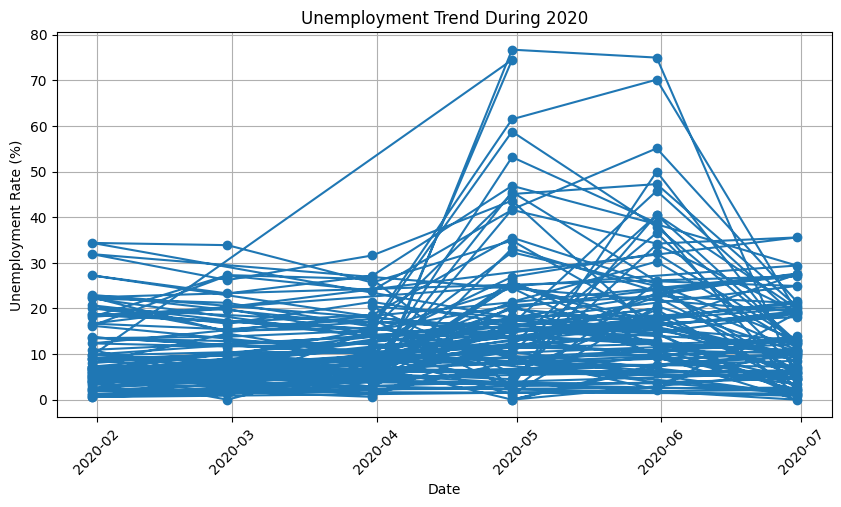

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    covid_data["Date"],
    covid_data["Estimated Unemployment Rate (%)"],
    marker="o"
)
plt.title("Unemployment Trend During 2020")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
highest_2020 = covid_data.loc[
    covid_data["Estimated Unemployment Rate (%)"].idxmax()
]

lowest_2020 = covid_data.loc[
    covid_data["Estimated Unemployment Rate (%)"].idxmin()
]
print("Highest Unemployment in 2020:")
print(highest_2020[["Region", "Date", "Estimated Unemployment Rate (%)"]])
print("\nLowest Unemployment in 2020:")
print(lowest_2020[["Region", "Date", "Estimated Unemployment Rate (%)"]])

Highest Unemployment in 2020:
Region                                      Puducherry
Date                               2020-04-30 00:00:00
Estimated Unemployment Rate (%)                  76.74
Name: 627, dtype: object

Lowest Unemployment in 2020:
Region                                           Assam
Date                               2020-06-30 00:00:00
Estimated Unemployment Rate (%)                    0.0
Name: 25, dtype: object


In [ ]:
df["Month"] = df["Date"].dt.month
monthly_unemployment = df.groupby("Month")[
    "Estimated Unemployment Rate (%)"
].mean()
print("Average Unemployment Rate by Month:")
print(monthly_unemployment)

Average Unemployment Rate by Month:
Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


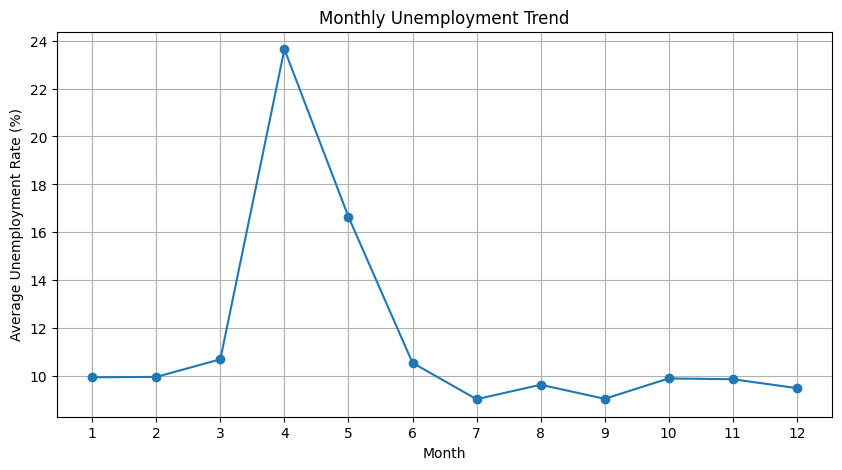

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)
plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

## Conclusion and Insights

1. The unemployment rate increased significantly from 2019 to 2020.

2. The average unemployment rate increased from 9.40% in 2019 to 15.10% in 2020.

3. The significant increase in 2020 indicates the impact of the COVID-19 period on employment in India.

4. The highest recorded unemployment rate was 76.74% in Puducherry on 30 April 2020.

5. The lowest recorded unemployment rate was 0% in Assam on 30 June 2020.

6. Tripura had the highest average unemployment rate among the regions, with an average of 28.35%.

7. Meghalaya had the lowest average unemployment rate among the regions, with an average of 4.80%.

8. Monthly analysis helps identify changes and patterns in unemployment rates over time.

9. The analysis can help policymakers develop employment opportunities, support unemployed people, and improve economic recovery programs.

10. Overall, the analysis shows that unemployment increased considerably during 2020 and highlights the importance of employment-support policies.